In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

print("[PREPROCESSING] Loading squat biomechanical data (YOLO 51-point format)...")

# Base path to squat dataset
base_path = r"C:\Users\Anxo\Desktop\Proyecto final 4\archive (3)\Squat_Data\Squat_Data"
X, y, temporal_sequence = [], [], []

for root, dirs, files in os.walk(base_path):
    sorted_files = sorted([f for f in files if f.endswith(".npy")])
    
    for file in sorted_files:
        file_path = os.path.join(root, file)
        try:
            keypoints_raw = np.load(file_path)
            if keypoints_raw.shape == (132,):
                # Extract YOLO keypoint indices (17 points * 3 coordinates = 51)
                yolo_indices = [0, 2, 5, 7, 8, 11, 12, 13, 14, 15, 16, 23, 24, 25, 26, 27, 28]
                points_yolo = []
                for idx in yolo_indices:
                    points_yolo.extend(keypoints_raw[idx*4 : idx*4+3])
                
                points_yolo = np.array(points_yolo)
                
                # Normalize by centering on hip center
                hip_left = points_yolo[11*3 : 11*3+3]
                hip_right = points_yolo[12*3 : 12*3+3]
                hip_center = (hip_left + hip_right) / 2
                
                keypoints_normalized = points_yolo.copy()
                for i in range(17):
                    keypoints_normalized[i*3 : i*3+3] -= hip_center
                
                temporal_sequence.append(keypoints_normalized)
            
            if len(temporal_sequence) == 30:
                X.append(temporal_sequence)
                y.append(1 if "Valid" in root else 0)
                
                # Apply mirror augmentation for improved generalization
                mirrored_sequence = np.array(temporal_sequence).copy()
                mirrored_sequence[:, 0::3] *= -1  
                
                X.append(mirrored_sequence)
                y.append(1 if "Valid" in root else 0)
                
                temporal_sequence = [] 
        except:
            continue

# Prepare final dataset
X = np.array(X)
y = to_categorical(y).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("[DATA] Preprocessing complete")
print(f"[DATA] X_train shape (samples, timesteps, features): {X_train.shape}")

[PREPROCESSING] Loading squat biomechanical data (YOLO 51-point format)...
[DATA] Preprocessing complete
[DATA] X_train shape (samples, timesteps, features): (1144, 30, 51)


In [5]:
print("[MODEL] Constructing LSTM neural network architecture...")

model_lstm = keras.Sequential([
    # Input synchronized with YOLO pose keypoints (30 frames x 51 coordinates)
    layers.Input(shape=(30, 51)),
    
    # LSTM layers with temporal sequence learning
    layers.LSTM(64, return_sequences=True, activation='tanh'),
    layers.Dropout(0.2),
    
    layers.LSTM(128, return_sequences=True, activation='tanh'),
    layers.Dropout(0.2),
    
    layers.LSTM(64, return_sequences=False, activation='tanh'),
    layers.Dropout(0.2),
    
    # Dense layers for classification
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    
    # Output: binary classification (invalid/valid squat)
    layers.Dense(2, activation='softmax')
])

model_lstm.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])
model_lstm.summary()

[MODEL] Constructing LSTM neural network architecture...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        29,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 184,226 (719.63 KB)

 Trainable params: 184,226 (719.63 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
print("[TRAINING] Starting model training on biomechanical dataset...")

# Early stopping to prevent overfitting
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_categorical_accuracy', 
    patience=20, 
    restore_best_weights=True
)

# Save best model during training
model_checkpoint = keras.callbacks.ModelCheckpoint(
    'modelo_squat_biomecanico.h5', 
    monitor='val_categorical_accuracy',
    save_best_only=True
)

# Train the model
history = model_lstm.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint]
)

print("[TRAINING] Model training complete. Saved as 'modelo_squat_biomecanico.h5'")

[TRAINING] Starting model training on biomechanical dataset...
Epoch 1/150
34/36 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - categorical_accuracy: 0.4979 - loss: 0.6956

36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - categorical_accuracy: 0.5026 - loss: 0.6928 - val_categorical_accuracy: 0.5420 - val_loss: 0.6859
Epoch 2/150
34/36 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - categorical_accuracy: 0.5096 - loss: 0.6930

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - categorical_accuracy: 0.5332 - loss: 0.6871 - val_categorical_accuracy: 0.5559 - val_loss: 0.7110
Epoch 3/150
35/36 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - categorical_accuracy: 0.5391 - loss: 0.6908

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - categorical_accuracy: 0.5638 - loss: 0.6774 - val_categorical_accuracy: 0.5699 - val_loss: 0.6675
Epoch 4/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - categorical_accuracy: 0.5871 - loss: 0.6675

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - categorical_accuracy: 0.5935 - loss: 0.6563 - val_categorical_accuracy: 0.6049 - val_loss: 0.6412
Epoch 5/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - categorical_accuracy: 0.5988 - loss: 0.6471 - val_categorical_accuracy: 0.5909 - val_loss: 0.6466
Epoch 6/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - categorical_accuracy: 0.6408 - loss: 0.6206

...

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - categorical_accuracy: 0.8969 - loss: 0.2158 - val_categorical_accuracy: 0.8811 - val_loss: 0.2283
Epoch 53/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - categorical_accuracy: 0.8986 - loss: 0.2033 - val_categorical_accuracy: 0.8531 - val_loss: 0.2737
Epoch 54/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - categorical_accuracy: 0.8934 - loss: 0.1991 - val_categorical_accuracy: 0.8531 - val_loss: 0.2684
Epoch 55/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - categorical_accuracy: 0.8907 - loss: 0.2130 - val_categorical_accuracy: 0.8776 - val_loss: 0.2794
Epoch 56/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - categorical_accuracy: 0.8864 - loss: 0.2105 - val_categorical_accuracy: 0.8322 - val_loss: 0.3416
Epoch 57/150
35/36 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - categorical_accuracy: 0.9028 - loss: 0.2062

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - categorical_accuracy: 0.9012 - loss: 0.2088 - val_categorical_accuracy: 0.9126 - val_loss: 0.2631
Epoch 58/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - categorical_accuracy: 0.9030 - loss: 0.2018 - val_categorical_accuracy: 0.8951 - val_loss: 0.2213
Epoch 59/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - categorical_accuracy: 0.9108 - loss: 0.1752 - val_categorical_accuracy: 0.8811 - val_loss: 0.2269
Epoch 60/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - categorical_accuracy: 0.9126 - loss: 0.1748 - val_categorical_accuracy: 0.8776 - val_loss: 0.2249
Epoch 61/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - categorical_accuracy: 0.9257 - loss: 0.1551 - val_categorical_accuracy: 0.8671 - val_loss: 0.2653
Epoch 62/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - categorical_accuracy: 0.9047 - loss: 0.2060 - val_categorical_accuracy: 0.8462 - val_loss: 0.3761
Epoch 63/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - categorical_accuracy: 0.8899 - loss: 0.2

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - categorical_accuracy: 0.9397 - loss: 0.1283 - val_categorical_accuracy: 0.9196 - val_loss: 0.2011
Epoch 74/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - categorical_accuracy: 0.9248 - loss: 0.1610 - val_categorical_accuracy: 0.8881 - val_loss: 0.2370
Epoch 75/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - categorical_accuracy: 0.9126 - loss: 0.2011 - val_categorical_accuracy: 0.8916 - val_loss: 0.2197
Epoch 76/150
35/36 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - categorical_accuracy: 0.9499 - loss: 0.1328

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - categorical_accuracy: 0.9441 - loss: 0.1345 - val_categorical_accuracy: 0.9266 - val_loss: 0.1941
Epoch 77/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - categorical_accuracy: 0.9240 - loss: 0.1509 - val_categorical_accuracy: 0.9126 - val_loss: 0.2957
Epoch 78/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - categorical_accuracy: 0.9476 - loss: 0.1185 - val_categorical_accuracy: 0.9091 - val_loss: 0.2065
Epoch 79/150
34/36 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - categorical_accuracy: 0.9403 - loss: 0.1442

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - categorical_accuracy: 0.9467 - loss: 0.1249 - val_categorical_accuracy: 0.9441 - val_loss: 0.1793
Epoch 80/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - categorical_accuracy: 0.9484 - loss: 0.1207 - val_categorical_accuracy: 0.9231 - val_loss: 0.1706
Epoch 81/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - categorical_accuracy: 0.9484 - loss: 0.1151 - val_categorical_accuracy: 0.8776 - val_loss: 0.2915
Epoch 82/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - categorical_accuracy: 0.9406 - loss: 0.1480 - val_categorical_accuracy: 0.9196 - val_loss: 0.1907
Epoch 83/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - categorical_accuracy: 0.9371 - loss: 0.1484 - val_categorical_accuracy: 0.9406 - val_loss: 0.2053
Epoch 84/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - categorical_accuracy: 0.9502 - loss: 0.1055 - val_categorical_accuracy: 0.9161 - val_loss: 0.1835
Epoch 85/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - categorical_accuracy: 0.9467 - loss: 0.1

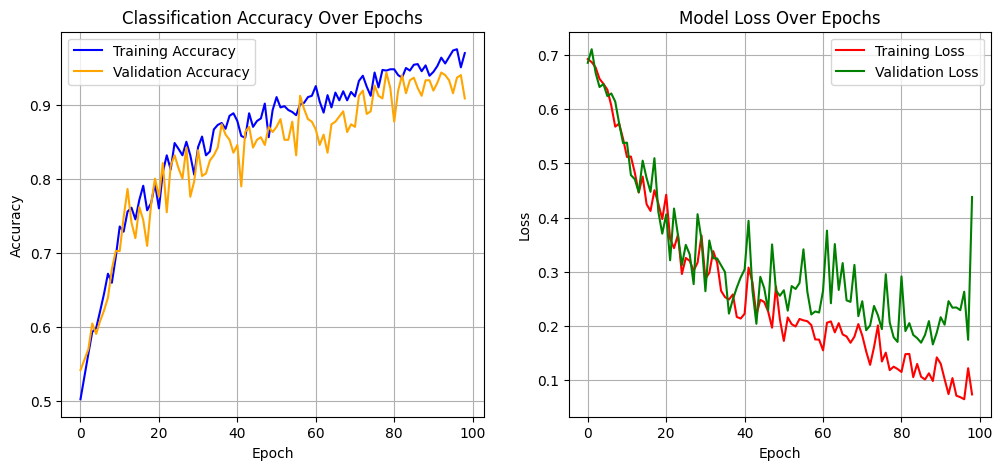

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - categorical_accuracy: 0.9441 - loss: 0.1793
[EVALUATION] Test set categorical_accuracy: 94.41%
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

[EVALUATION] Confusion Matrix:
[[126   5]
 [ 11 144]]

[EVALUATION] Classification Report:
              precision    recall  f1-score   support

     Invalid       0.92      0.96      0.94       131
       Valid       0.97      0.93      0.95       155

    accuracy                           0.94       286
   macro avg       0.94      0.95      0.94       286
weighted avg       0.95      0.94      0.94       286


[METRICS] Global model summary:
Accuracy: 0.944
Precision: 0.966
Recall: 0.929
F1-Score: 0.947


In [8]:
# Visualize training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['categorical_accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_categorical_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Classification Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss evolution
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='green')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Evaluate on test set
# Evaluate returns [loss, categorical_accuracy] for a multi-class model.
test_results = model_lstm.evaluate(X_test, y_test)
print(f"[EVALUATION] Test set categorical_accuracy: {round(test_results[1] * 100, 2)}%")

# Perform predictions on the test set
y_pred = model_lstm.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Import additional metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Confusion matrix and classification report
cm = confusion_matrix(y_true_classes, y_pred_classes)
print("\n[EVALUATION] Confusion Matrix:")
print(cm)
report = classification_report(y_true_classes, y_pred_classes, target_names=['Invalid', 'Valid'])
print("\n[EVALUATION] Classification Report:")
print(report)

# Global metrics: accuracy, precision, recall and F1-score
accuracy = accuracy_score(y_true_classes, y_pred_classes)
precision = precision_score(y_true_classes, y_pred_classes, pos_label=1)
recall = recall_score(y_true_classes, y_pred_classes, pos_label=1)
f1 = f1_score(y_true_classes, y_pred_classes, pos_label=1)

print("\n[METRICS] Global model summary:")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1:.3f}")


In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO
from tensorflow.keras.models import load_model

print("[VIRTUAL JUDGE] Loading models for real-time squat validation...")

# Initialize models
model_judge = load_model('modelo_squat_biomecanico.h5')
pose_detector = YOLO('yolov8n-pose.pt')

# Video source (change to 0 for webcam)
video_source = r"C:\Users\Anxo\Downloads\455kg squat FIGHT Jesus Olivares.mp4" 
cap = cv2.VideoCapture(video_source)

# State tracking
keypoint_buffer = []
prediction_text = "SYSTEM READY"
text_color = (255, 255, 255)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret: 
        break
    
    # Process frame
    frame_resized = cv2.resize(frame, (800, 600))
    detection = pose_detector.predict(frame_resized, conf=0.5, verbose=False)
    
    if detection[0].keypoints and len(detection[0].keypoints.data) > 0:
        keypoints = detection[0].keypoints.data[0].cpu().numpy().flatten()
        
        # Ensure valid YOLO keypoints (51 values)
        if len(keypoints) == 51:
            
            # Normalize keypoints by hip center
            hip_left = keypoints[11*3 : 11*3+3]
            hip_right = keypoints[12*3 : 12*3+3]
            hip_center = (hip_left + hip_right) / 2
            
            keypoints_normalized = keypoints.copy()
            for i in range(17):
                keypoints_normalized[i*3 : i*3+3] -= hip_center
            
            keypoint_buffer.append(keypoints_normalized)
            if len(keypoint_buffer) > 30: 
                keypoint_buffer.pop(0)
            
            # Make prediction with full buffer
            if len(keypoint_buffer) == 30:
                prediction = model_judge.predict(np.expand_dims(keypoint_buffer, axis=0), verbose=0)[0]
                
                # Interpret prediction (pred[0]=invalid, pred[1]=valid)
                if prediction[1] > prediction[0]:
                    prediction_text = f"VALID ({prediction[1]*100:.1f}%)"
                    text_color = (0, 255, 0)
                else:
                    prediction_text = f"INVALID ({prediction[0]*100:.1f}%)"
                    text_color = (0, 0, 255)
                    
        # Render skeleton with verdict
        frame_display = detection[0].plot()
        cv2.putText(frame_display, prediction_text, (30, 60), cv2.FONT_HERSHEY_SIMPLEX, 1.5, text_color, 4)
        
    cv2.imshow("Virtual Referee - Squat Validator", frame_display)
    
    # Exit on 'q' key
    if cv2.waitKey(10) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

🎥 Iniciando el Juez Virtual (YOLOv8 + LSTM)...


In [ ]:
import os
import numpy as np
import cv2
import random
from tensorflow.keras.models import load_model

# Load LSTM model for inference
try:
    model_lstm = load_model('modelo_squat_biomecanico.h5')
    print("[GAME] LSTM model loaded successfully")
except:
    print("[ERROR] modelo_squat_biomecanico.h5 not found. Train the model first.")
    raise

# Dataset path
dataset_root = r"C:\Users\Anxo\Desktop\Proyecto final 4\archive (3)\Squat_Data\Squat_Data"

# Skeleton keypoint connections
SKELETON_LINKS = [
    # Torso and head (red)
    ((11, 12), (255, 0, 0)), ((11, 23), (255, 0, 0)), ((12, 24), (255, 0, 0)), ((23, 24), (255, 0, 0)),
    ((8, 6), (255, 0, 0)), ((6, 5), (255, 0, 0)), ((5, 4), (255, 0, 0)), ((4, 0), (255, 0, 0)),
    ((0, 1), (255, 0, 0)), ((1, 2), (255, 0, 0)), ((2, 3), (255, 0, 0)), ((3, 7), (255, 0, 0)),
    # Arms (green)
    ((11, 13), (0, 255, 0)), ((13, 15), (0, 255, 0)), ((15, 17), (0, 255, 0)), ((15, 19), (0, 255, 0)), ((15, 21), (0, 255, 0)),
    ((12, 14), (0, 255, 0)), ((14, 16), (0, 255, 0)), ((16, 18), (0, 255, 0)), ((16, 20), (0, 255, 0)), ((16, 22), (0, 255, 0)),
    # Legs (blue)
    ((23, 25), (0, 0, 255)), ((25, 27), (0, 0, 255)), ((27, 29), (0, 0, 255)), ((27, 31), (0, 0, 255)),
    ((24, 26), (0, 0, 255)), ((26, 28), (0, 0, 255)), ((28, 30), (0, 0, 255)), ((28, 32), (0, 0, 255))
]

def draw_skeleton(keypoints_normalized):
    """Render articulated skeleton on black canvas"""
    canvas = np.zeros((600, 800, 3), dtype=np.uint8)
    keypoint_pixels = []
    
    # Extract and scale keypoints
    for i in range(33):
        x = int(keypoints_normalized[i*4] * 800)
        y = int(keypoints_normalized[i*4 + 1] * 600)
        keypoint_pixels.append((x, y))
        # Draw keypoint
        if 0 <= x < 800 and 0 <= y < 600:
            cv2.circle(canvas, (x, y), 3, (255, 255, 255), -1)

    # Draw connection lines
    for connection, color in SKELETON_LINKS:
        p1_idx, p2_idx = connection
        p1 = keypoint_pixels[p1_idx]
        p2 = keypoint_pixels[p2_idx]
        
        if (0 <= p1[0] < 800 and 0 <= p1[1] < 600) and \
           (0 <= p2[0] < 800 and 0 <= p2[1] < 600):
            cv2.line(canvas, p1, p2, color, 2)
            
    return canvas

def play_training_round():
    """Execute one game round"""
    # Random class selection
    target_class = random.choice([0, 1])
    class_name = "Valid" if target_class == 1 else "Invalid"
    class_path = os.path.join(dataset_root, class_name)
    
    # Select random squat sample
    sample_dirs = [d for d in os.listdir(class_path) if os.path.isdir(os.path.join(class_path, d))]
    sample_id = random.choice(sample_dirs)
    sample_path = os.path.join(class_path, sample_id)
    keypoint_files = sorted([f for f in os.listdir(sample_path) if f.endswith('.npy')])
    
    if len(keypoint_files) < 30: 
        return play_training_round()

    model_sequence = []
    yolo_indices = [0, 2, 5, 7, 8, 11, 12, 13, 14, 15, 16, 23, 24, 25, 26, 27, 28]
    
    # Playback skeleton animation
    print(f"[GAME] Analyzing: {class_name}/{sample_id}")
    for i in range(min(len(keypoint_files), 70)):
        data = np.load(os.path.join(sample_path, keypoint_files[i]))
        
        # Render skeleton
        skeleton_img = draw_skeleton(data)
        cv2.putText(skeleton_img, "Watch the depth and form", (150, 40), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
        cv2.imshow('Squat Classifier Training Game', skeleton_img)
        cv2.waitKey(40)
        
        # Collect first 30 frames for model
        if i < 30:
            yolo_points = []
            for idx in yolo_indices:
                yolo_points.extend(data[idx*4 : idx*4+3])
            model_sequence.append(yolo_points)

    # Player voting phase
    print("[GAME] Player vote: [v] Valid or [n] Invalid?")
    player_vote = None
    while player_vote not in ['v', 'n']:
        key = cv2.waitKey(0) & 0xFF
        if key == ord('v'): 
            player_vote = 'v'
        elif key == ord('n'): 
            player_vote = 'n'
    
    player_label = 1 if player_vote == 'v' else 0
    
    # Model prediction
    prediction = model_lstm.predict(np.expand_dims(model_sequence, axis=0), verbose=0)[0]
    model_label = np.argmax(prediction)
    model_confidence = prediction[model_label] * 100
    
    # Results display
    result_canvas = np.zeros((600, 800, 3), dtype=np.uint8)
    player_correct = player_label == target_class
    player_color = (0, 255, 0) if player_correct else (0, 0, 255)
    model_correct = model_label == target_class
    model_color = (0, 255, 0) if model_correct else (0, 0, 255)
    
    cv2.putText(result_canvas, f"Your Choice: {player_vote.upper()}", (100, 150), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255,255,255), 3)
    cv2.putText(result_canvas, f"Ground Truth: {class_name.upper()}", (100, 250), cv2.FONT_HERSHEY_SIMPLEX, 1.5, player_color, 3)
    cv2.putText(result_canvas, f"Model Prediction: {'VALID' if model_label == 1 else 'INVALID'}", (100, 380), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (200,200,200), 2)
    cv2.putText(result_canvas, f"Model Confidence: {model_confidence:.1f}%", (100, 430), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (150,150,150), 1)
    
    result_msg = "Your prediction matches!" if player_correct else "Database indicates otherwise"
    cv2.putText(result_canvas, result_msg, (100, 520), cv2.FONT_HERSHEY_SIMPLEX, 1, player_color, 2)
    cv2.putText(result_canvas, "Press any key for next round (q to quit)", (120, 570), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 1)
    
    cv2.imshow('Squat Classifier Training Game', result_canvas)
    
    final_key = cv2.waitKey(0) & 0xFF
    if final_key == ord('q'):
        return False
    return True

# Start game
print("[GAME] Starting Interactive Squat Form Training")
print("[GAME] Instructions: Watch the skeleton, evaluate valid/invalid form")
print("[GAME] Vote with 'v' (valid) or 'n' (invalid). Press 'q' to exit.")

try:
    active = True
    while active:
        active = play_training_round()
except KeyboardInterrupt:
    print("\n[GAME] Interrupted by user")
finally:
    cv2.destroyAllWindows()
    print("[GAME] Training session ended")

✅ Modelo IA cargado correctamente.
🎮 BIENVENIDO AL JUEGO 'STICKMAN SQUAT JUDGE'
Instrucciones: Mira el movimiento del muñeco articulado.
Cuando se detenga, pulsa 'v' para Válida o 'n' para Nula.
Pulsa 'q' en la pantalla de resultados para salir.
🎬 Analizando movimiento en: Valid/55...

❓ ¿Es VALIDA (pulsa 'v') o NULA (pulsa 'n')?
🎬 Analizando movimiento en: Valid/112...

❓ ¿Es VALIDA (pulsa 'v') o NULA (pulsa 'n')?
🎬 Analizando movimiento en: Valid/79...

❓ ¿Es VALIDA (pulsa 'v') o NULA (pulsa 'n')?
🎬 Analizando movimiento en: Valid/3...

❓ ¿Es VALIDA (pulsa 'v') o NULA (pulsa 'n')?
🎬 Analizando movimiento en: Valid/55...

❓ ¿Es VALIDA (pulsa 'v') o NULA (pulsa 'n')?
🎬 Analizando movimiento en: Valid/35...

❓ ¿Es VALIDA (pulsa 'v') o NULA (pulsa 'n')?
🎬 Analizando movimiento en: Valid/22...

❓ ¿Es VALIDA (pulsa 'v') o NULA (pulsa 'n')?
🎬 Analizando movimiento en: Valid/98...

❓ ¿Es VALIDA (pulsa 'v') o NULA (pulsa 'n')?
👋 ¡Gracias por jugar! El juez de hierro se despide.


In [ ]:
import cv2
from ultralytics import YOLO
import numpy as np
from tensorflow.keras.models import load_model
import time

# Load models
print("[COACH] Loading inference models...")
model_lstm = load_model('modelo_squat_biomecanico.h5')
pose_model = YOLO('yolov8n-pose.pt')

# Video source (change to 0 for live webcam)
cap = cv2.VideoCapture(r"C:\Users\Anxo\Downloads\455kg squat FIGHT Jesus Olivares.mp4")

# Coaching state variables
keypoint_sequence = []
repetition_count = 0
movement_state = "IDLE"
max_valid_confidence = 0
shoulder_y_baseline = None
max_torso_angle = 0
coach_instruction = "System ready - waiting for descent"
indicator_color = (100, 100, 100)

def compute_torso_angle(keypoints):
    """Calculate torso inclination angle relative to vertical"""
    shoulder = keypoints[5]
    hip = keypoints[11]
    
    delta_y = hip[1] - shoulder[1]
    delta_x = hip[0] - shoulder[0]
    
    angle = np.abs(np.degrees(np.arctan2(delta_x, delta_y)))
    return angle

print("[COACH] Real-time coaching system initialized...")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret: 
        break
    
    # Process video frame
    frame = cv2.resize(frame, (800, 600))
    results = pose_model.predict(frame, conf=0.3, verbose=False)
    
    if results[0].keypoints and len(results[0].keypoints.data) > 0:
        keypoints_data = results[0].keypoints.data[0].cpu().numpy()
        shoulder_y = (keypoints_data[5][1] + keypoints_data[6][1]) / 2
        
        if shoulder_y_baseline is None:
            shoulder_y_baseline = shoulder_y
            continue

        # Extract normalized keypoints for model
        keypoints_flat = keypoints_data.flatten()
        if len(keypoints_flat) == 51:
            keypoint_sequence.append(keypoints_flat)
        if len(keypoint_sequence) > 30: 
            keypoint_sequence.pop(0)

        # Coaching analysis
        descent_magnitude = shoulder_y - shoulder_y_baseline
        current_torso_angle = compute_torso_angle(keypoints_data)

        # Detect descent phase
        if descent_magnitude > 40 and movement_state == "IDLE":
            movement_state = "DESCENDING"
            max_valid_confidence = 0
            max_torso_angle = 0
            coach_instruction = "Descending... Maintain chest position"
            indicator_color = (100, 100, 100)

        # Monitor during descent
        if movement_state == "DESCENDING":
            if current_torso_angle > max_torso_angle:
                max_torso_angle = current_torso_angle
            
            if len(keypoint_sequence) == 30:
                prediction = model_lstm.predict(np.expand_dims(keypoint_sequence, axis=0), verbose=0)[0]
                if prediction[1] > max_valid_confidence:
                    max_valid_confidence = prediction[1]

        # Detect end of repetition (ascent)
        if descent_magnitude < 30 and movement_state == "DESCENDING":
            # Evaluate rep validity
            if max_valid_confidence > 0.70:
                repetition_count += 1
                indicator_color = (255, 255, 255)
                # Form feedback
                if max_torso_angle > 35:
                    coach_instruction = f"Valid rep. Form: Torso angle {int(max_torso_angle)}° - strengthen trunk."
                else:
                    coach_instruction = "Perfect repetition! Good posture and depth achieved."
            else:
                indicator_color = (0, 0, 255)
                coach_instruction = "Invalid rep. Insufficient depth - check ankle mobility."
            
            movement_state = "IDLE"

    # Render interface
    frame_annotated = results[0].plot()
    
    # Coaching instruction panel
    cv2.rectangle(frame_annotated, (0, 530), (800, 600), (0, 0, 0), -1)
    cv2.putText(frame_annotated, coach_instruction, (20, 570), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
    
    # Traffic light indicator
    for i in range(3):
        cv2.circle(frame_annotated, (650 + (i*45), 45), 18, indicator_color, -1)
        cv2.circle(frame_annotated, (650 + (i*45), 45), 18, (255, 255, 255), 1)

    # Rep counter display
    cv2.rectangle(frame_annotated, (0, 0), (200, 60), (0, 0, 0), -1)
    cv2.putText(frame_annotated, f"Reps: {repetition_count}", (20, 45), 
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 3)

    cv2.imshow('AI Squat Coach', frame_annotated)
    if cv2.waitKey(1) & 0xFF == ord('q'): 
        break

cap.release()
cv2.destroyAllWindows()
print("[COACH] Coaching session ended")

🚀 Coach Inteligente Activado...
